# **Mandelbrot Set Generator**

The **Mandelbrot Set** is a famous **mathematical fractal** created by repeatedly applying a simple equation to complex numbers. Although the rule is very simple, it produces an infinitely detailed and beautiful shape.





$$z_{n+1} = z_n^2 + c$$


starting with

$$
z_0 = 0
$$

**never grows to infinity**.

If the values stay bounded, the point belongs to the Mandelbrot Set. If they eventually become very large, the point is outside the set.

---

## The Formula

The entire Mandelbrot Set comes from one simple equation:


$$z_{n+1}=z_n^2+c
$$

where:

* **(z)** is a complex number that changes each iteration.
* **(c)** is a fixed complex number (one point on the complex plane).
* Start with (z=0).



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from PIL import Image

In [27]:
def mandelbrot_gen(image_width : int, image_height : int , itertations: int) -> NDArray:

    grid = np.zeros((image_height , image_width , 3) , dtype=np.uint8)
    Real = np.linspace(-2 , 1 , image_width)
    imaginary  = np.linspace(-1.5 , 1.5 , image_height)
    max_iterations = itertations
    for index_row in range(image_height):

         
        for index_col in range(image_width):
            real = Real[index_col]
            img = imaginary[index_row]
            c = real + img *1j
            z = 0
            for index in range(max_iterations):
                z = z*z + c
                if (z.real * z.real) + (z.imag * z.imag) > 4 :
                    break
                    
            if index == max_iterations - 1:
                R , G , B = 0, 0, 0
            else:

                t = index / max_iterations

                R = int(9 * (1 - t) * t**3 * 255)
                G = int(15 * (1 - t)**2 * t**2 * 255)
                B = int(8.5 * (1 - t)**3 * t * 255)
                    
            
            
            
            grid[index_row, index_col] = (R ,G ,B)



    return grid

array = mandelbrot_gen(1920 ,1080 ,100)

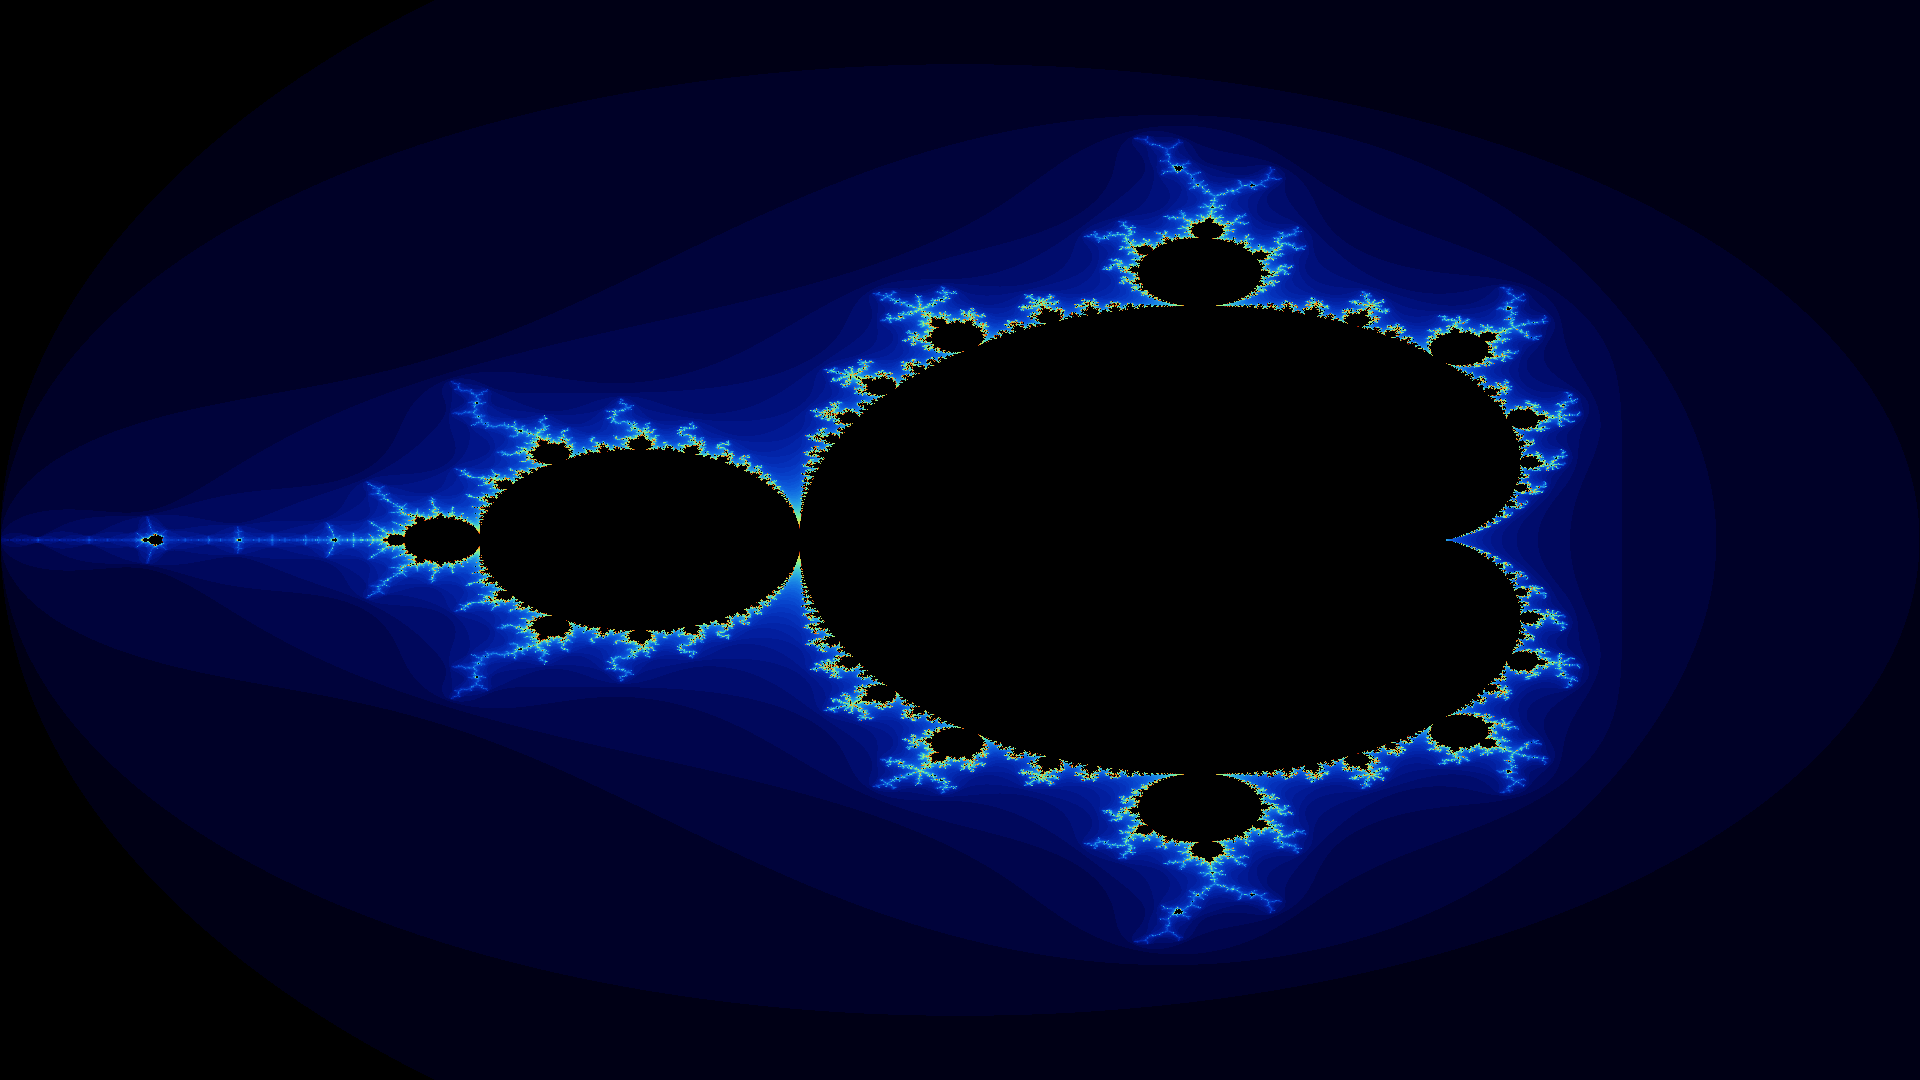

In [28]:
Image.fromarray(array)
# image.show()
# 1 : 49.8

# **Infinite Mandelbort Generator**


An infinite Mandelbrot zoom is created by repeatedly rendering the Mandelbrot Set while continuously shrinking the visible region around a fixed point in the complex plane. Each rendered image becomes one frame of a video, creating the illusion of endlessly zooming into the fractal.

---

# Step 1: Choose the Initial Viewing Window

Start by defining the region of the complex plane that will be displayed.

```text
Real Axis:
-2 ----------------------------> 1

Imaginary Axis:
-1.5
 |
 |
 |
1.5
```

Initial coordinates:

```python
x_min = -2
x_max = 1

y_min = -1.5
y_max = 1.5
```

---

# Step 2: Select a Zoom Center

Choose the point that the camera will continuously zoom toward.

Example:

```python
center_x = -0.743643887037151
center_y = 0.131825904205330
```

This point remains at the center of every frame.

---

# Step 3: Render the First Frame

Generate the Mandelbrot image using the current coordinates.

```python
image = mandelbrot_gen(
    width,
    height,
    x_min,
    x_max,
    y_min,
    y_max,
    max_iterations
)
```

Save the image.

```python
Image.fromarray(image).save("frame0000.png")
```

---

# Step 4: Compute the Current Window Size

Calculate the width and height of the visible region.

```python
width = x_max - x_min
height = y_max - y_min
```

Initially,

```text
Width  = 3
Height = 3
```

---

# Step 5: Shrink the Viewing Window

Multiply the width and height by a zoom factor.

Example:

```python
zoom_factor = 0.97
```

Update:

```python
width *= zoom_factor
height *= zoom_factor
```

The visible area becomes 97% of the previous frame.

Example:

```text
Frame 1

Width = 3.00

↓

Frame 2

Width = 2.91

↓

Frame 3

Width = 2.82

↓

...
```

---

# Step 6: Recalculate the Coordinates

Keep the selected point in the center while shrinking the viewing window.

```python
x_min = center_x - width / 2
x_max = center_x + width / 2

y_min = center_y - height / 2
y_max = center_y + height / 2
```

Visual representation:

```text
Frame 1

+------------------------+
|                        |
|          ●             |
|                        |
+------------------------+

Frame 2

    +----------------+
    |       ●        |
    +----------------+

Frame 3

        +---------+
        |    ●    |
        +---------+
```

The point **●** never moves.

---

# Step 7: Increase the Maximum Iterations

As the zoom becomes deeper, more iterations are required to preserve fine details.

Example:

```python
max_iterations = int(max_iterations * 1.01)
```

Iteration progression:

```text
Frame 1

500

↓

Frame 50

822

↓

Frame 100

1350

↓

Frame 300

9900
```

---

# Step 8: Render the Next Frame

Generate another Mandelbrot image using the updated coordinates.

```python
image = mandelbrot_gen(
    width,
    height,
    x_min,
    x_max,
    y_min,
    y_max,
    max_iterations
)
```

Save the frame.

```python
frame0001.png
```

---

# Step 9: Repeat the Process

Repeat the following steps for every frame:

1. Render the Mandelbrot image.
2. Save the frame.
3. Shrink the viewing window.
4. Recalculate the coordinates.
5. Increase the maximum iterations.

Pseudo-code:

```text
for each frame

    Render Mandelbrot

    Save Image

    Shrink Viewing Window

    Center Around Zoom Point

    Increase Iterations
```

---

# Step 10: Combine Frames into a Video

After all frames are generated, combine them into a video using FFmpeg.

Example command:

```bash
ffmpeg -framerate 60 -i frame_%04d.png -c:v libx264 -pix_fmt yuv420p mandelbrot_zoom.mp4
```

---

# Why Does the Zoom Appear Infinite?

The Mandelbrot Set is a **fractal**, meaning it contains self-similar structures at every scale.

Each time the viewing window shrinks, new details become visible.

Mathematically, there is no final level of detail, so the zoom can continue indefinitely. The practical limits are the computer's floating-point precision, available memory, rendering time, and the chosen iteration count.

# The videos of different region of Madelbrot set are below:
* 1 . **[Seashore Valley](./Vidoes/Seashore_valley.mp4)**
* 2 . **[Antenna Tip](./Vidoes/Antenna_tip.mp4)**
* 3 . **[Elephant Valley](./Vidoes/elephant_valley.mp4)**
* 3 . **[Triple Spiral](./Vidoes/triple_spiral.mp4)**